# Entrenamiento de Redes Neuronales mediante PSO sin Retropropagación



## 1. Introducción

El entrenamiento clásico de redes neuronales se realiza mediante el algoritmo de **retropropagación del error (backpropagation)** combinado con descenso del gradiente. Sin embargo, este enfoque presenta limitaciones conocidas:

- Sensibilidad a la inicialización de pesos.
- Posibilidad de quedar atrapado en mínimos locales.
- Requiere que la función de pérdida sea diferenciable.
- El cálculo del gradiente puede ser numéricamente inestable en redes profundas.

Los **algoritmos de enjambre** ofrecen una alternativa libre de gradiente para optimizar los pesos y sesgos de una red neuronal. En este notebook se implementa el entrenamiento de una **red neuronal de tres capas** utilizando **PSO** como optimizador de los parámetros del modelo.

### Arquitectura de la Red Neuronal

```
Capa de Entrada   →   Capa Oculta 1   →   Capa Oculta 2   →   Capa de Salida
   (d neuronas)       (H1 neuronas)       (H2 neuronas)        (C neuronas)
      ReLU               ReLU             Softmax (clasificación)
```


## 2. Conjunto de Datos

Se utiliza el conjunto de datos **Iris** (UCI), un benchmark clásico de clasificación multiclase:

- **Muestras:** 150
- **Características:** 4 (longitud y ancho de sépalo y pétalo)
- **Clases:** 3 (Setosa, Versicolor, Virginica)
- **Tarea:** Clasificación multiclase


In [1]:
# ============================================================
# IMPORTACIÓN DE BIBLIOTECAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

np.random.seed(42)
print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


In [2]:
# ============================================================
# CARGA Y PREPARACIÓN DEL DATASET IRIS
# ============================================================
iris = load_iris()
X_raw = iris.data
y_raw = iris.target
class_names = iris.target_names
feature_names = iris.feature_names

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Codificación one-hot para las etiquetas
n_classes = len(np.unique(y_raw))
Y_onehot = np.eye(n_classes)[y_raw]

# División entrenamiento / prueba
X_train, X_test, y_train, y_test, Y_train, Y_test = train_test_split(
    X_scaled, y_raw, Y_onehot, test_size=0.25, random_state=42, stratify=y_raw
)

print(f"Dimensiones originales:   {X_raw.shape}")
print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba:        {X_test.shape}")
print(f"Clases: {class_names}")

df_iris = pd.DataFrame(X_raw, columns=feature_names)
df_iris['clase'] = [class_names[i] for i in y_raw]
print("\nPrimeras filas del dataset:")
df_iris.head(10)

Dimensiones originales:   (150, 4)
Conjunto de entrenamiento: (112, 4)
Conjunto de prueba:        (38, 4)
Clases: ['setosa' 'versicolor' 'virginica']

Primeras filas del dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## 3. Arquitectura de la Red Neuronal

La red neuronal implementada tiene la siguiente estructura:

| Capa | Tipo | Neuronas | Activación |
|---|---|---|---|
| Entrada | Input | 4 | — |
| Oculta 1 | Dense | 10 | ReLU |
| Oculta 2 | Dense | 8 | ReLU |
| Salida | Dense | 3 | Softmax |


In [3]:
# ============================================================
# DEFINICIÓN DE LA RED NEURONAL (IMPLEMENTACIÓN DESDE CERO)
# ============================================================
class NeuralNetwork:
    """
    Red neuronal de tres capas implementada desde cero.
    Los pesos y sesgos son optimizados externamente (sin backpropagation).

    Arquitectura: Input(d) -> Dense(H1, ReLU) -> Dense(H2, ReLU) -> Dense(C, Softmax)
    """

    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        self.input_size    = input_size
        self.hidden1_size  = hidden1_size
        self.hidden2_size  = hidden2_size
        self.output_size   = output_size

        # Calcular dimensiones de cada sección del vector de parámetros
        self.w1_size = input_size * hidden1_size
        self.b1_size = hidden1_size
        self.w2_size = hidden1_size * hidden2_size
        self.b2_size = hidden2_size
        self.w3_size = hidden2_size * output_size
        self.b3_size = output_size

        self.total_params = (self.w1_size + self.b1_size +
                             self.w2_size + self.b2_size +
                             self.w3_size + self.b3_size)

    def _relu(self, z):
        """Función de activación ReLU: max(0, z)."""
        return np.maximum(0, z)

    def _softmax(self, z):
        """Función Softmax numéricamente estable."""
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def decode_weights(self, theta):
        """
        Decodifica el vector de parámetros plano en matrices de pesos y sesgos.

        Parámetros:
        -----------
        theta : np.ndarray de forma (total_params,)
            Vector de parámetros de la partícula PSO.

        Retorna:
        --------
        W1, b1, W2, b2, W3, b3 : matrices y vectores de parámetros.
        """
        idx = 0
        W1 = theta[idx:idx+self.w1_size].reshape(self.input_size, self.hidden1_size)
        idx += self.w1_size
        b1 = theta[idx:idx+self.b1_size]
        idx += self.b1_size
        W2 = theta[idx:idx+self.w2_size].reshape(self.hidden1_size, self.hidden2_size)
        idx += self.w2_size
        b2 = theta[idx:idx+self.b2_size]
        idx += self.b2_size
        W3 = theta[idx:idx+self.w3_size].reshape(self.hidden2_size, self.output_size)
        idx += self.w3_size
        b3 = theta[idx:idx+self.b3_size]
        return W1, b1, W2, b2, W3, b3

    def forward(self, X, theta):
        """
        Propagación hacia adelante (forward pass).

        Parámetros:
        -----------
        X : np.ndarray de forma (n_samples, input_size)
        theta : np.ndarray - Vector de pesos de la partícula.

        Retorna:
        --------
        output : np.ndarray de forma (n_samples, output_size)
            Probabilidades de clase (salida Softmax).
        """
        W1, b1, W2, b2, W3, b3 = self.decode_weights(theta)

        # Capa oculta 1
        z1 = X @ W1 + b1
        a1 = self._relu(z1)

        # Capa oculta 2
        z2 = a1 @ W2 + b2
        a2 = self._relu(z2)

        # Capa de salida
        z3 = a2 @ W3 + b3
        output = self._softmax(z3)

        return output

    def predict(self, X, theta):
        """Devuelve la clase predicha para cada muestra."""
        probs = self.forward(X, theta)
        return np.argmax(probs, axis=1)

    def cross_entropy_loss(self, X, Y_onehot, theta):
        """
        Calcula la pérdida de entropía cruzada.

        Parámetros:
        -----------
        X : np.ndarray - Datos de entrada.
        Y_onehot : np.ndarray - Etiquetas en formato one-hot.
        theta : np.ndarray - Vector de parámetros.

        Retorna:
        --------
        loss : float - Pérdida promedio de entropía cruzada.
        """
        probs = self.forward(X, theta)
        probs = np.clip(probs, 1e-15, 1 - 1e-15)
        loss = -np.mean(np.sum(Y_onehot * np.log(probs), axis=1))
        return loss


# Instanciar la red neuronal
INPUT_SIZE   = X_train.shape[1]  # 4
HIDDEN1_SIZE = 10
HIDDEN2_SIZE = 8
OUTPUT_SIZE  = n_classes         # 3

nn = NeuralNetwork(INPUT_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE)

print(f"Arquitectura de la Red Neuronal")
print(f"{'Capa':<20} {'Entrada':>10} {'Salida':>10} {'Parámetros':>12}")
print("-" * 55)
print(f"{'Oculta 1 (ReLU)':<20} {INPUT_SIZE:>10} {HIDDEN1_SIZE:>10} {INPUT_SIZE*HIDDEN1_SIZE + HIDDEN1_SIZE:>12}")
print(f"{'Oculta 2 (ReLU)':<20} {HIDDEN1_SIZE:>10} {HIDDEN2_SIZE:>10} {HIDDEN1_SIZE*HIDDEN2_SIZE + HIDDEN2_SIZE:>12}")
print(f"{'Salida (Softmax)':<20} {HIDDEN2_SIZE:>10} {OUTPUT_SIZE:>10} {HIDDEN2_SIZE*OUTPUT_SIZE + OUTPUT_SIZE:>12}")
print("-" * 55)
print(f"{'TOTAL':<20} {'':>10} {'':>10} {nn.total_params:>12}")
print(f"\nDimensionalidad de la partícula PSO: {nn.total_params}")

Arquitectura de la Red Neuronal
Capa                    Entrada     Salida   Parámetros
-------------------------------------------------------
Oculta 1 (ReLU)               4         10           50
Oculta 2 (ReLU)              10          8           88
Salida (Softmax)              8          3           27
-------------------------------------------------------
TOTAL                                               165

Dimensionalidad de la partícula PSO: 165


## 4. Implementación de PSO para Entrenamiento de la Red Neuronal

In [4]:
# ============================================================
# FUNCIÓN DE APTITUD PARA ENTRENAMIENTO DE RED NEURONAL
# ============================================================
def fitness_nn(theta, nn_model, X_train, Y_train, X_val=None, Y_val=None):
    """
    Función de aptitud para el entrenamiento de red neuronal sin backpropagation.

    La aptitud es el negativo de la pérdida de entropía cruzada en el conjunto
    de entrenamiento. PSO maximiza, por lo que se minimiza la pérdida maximizando
    su negativo.

    Parámetros:
    -----------
    theta : np.ndarray - Vector de pesos de la red.
    nn_model : NeuralNetwork - Instancia del modelo.
    X_train : np.ndarray - Datos de entrenamiento.
    Y_train : np.ndarray - Etiquetas one-hot de entrenamiento.

    Retorna:
    --------
    float : Negativo de la pérdida de entropía cruzada.
    """
    loss = nn_model.cross_entropy_loss(X_train, Y_train, theta)
    return -loss  # PSO maximiza


print("Funcion de aptitud para entrenamiento de red neuronal definida.")
print("Objetivo: MINIMIZAR Entropia Cruzada (equivalente a MAXIMIZAR su negativo)")

Funcion de aptitud para entrenamiento de red neuronal definida.
Objetivo: MINIMIZAR Entropia Cruzada (equivalente a MAXIMIZAR su negativo)


In [5]:
# ============================================================
# PSO PARA ENTRENAMIENTO DE RED NEURONAL
# ============================================================
class PSONeuralTrainer:
    """
    Entrenador de red neuronal basado en PSO.
    Optimiza el vector completo de pesos y sesgos sin retropropagación.

    Parámetros:
    -----------
    nn_model : NeuralNetwork
        Instancia del modelo de red neuronal.
    n_particles : int
        Número de partículas en el enjambre.
    max_iter : int
        Número máximo de iteraciones de entrenamiento.
    w : float
        Coeficiente de inercia.
    c1, c2 : float
        Coeficientes cognitivo y social.
    init_range : float
        Rango de inicialización de pesos (Xavier-like).
    """

    def __init__(self, nn_model, n_particles=30, max_iter=200,
                 w=0.729, c1=1.494, c2=1.494, init_range=1.0):
        self.nn        = nn_model
        self.n_part    = n_particles
        self.max_iter  = max_iter
        self.w         = w
        self.c1        = c1
        self.c2        = c2
        self.n_dim     = nn_model.total_params
        self.init_range = init_range

        # Inicialización del enjambre
        # Inicialización tipo Xavier: escala proporcional a sqrt(6 / fan_in)
        self.positions  = np.random.uniform(-init_range, init_range,
                                            (self.n_part, self.n_dim))
        v_max = init_range * 0.2
        self.velocities = np.random.uniform(-v_max, v_max,
                                            (self.n_part, self.n_dim))

        self.p_best_pos = self.positions.copy()
        self.p_best_val = np.full(self.n_part, -np.inf)
        self.g_best_pos = None
        self.g_best_val = -np.inf

        # Historial
        self.loss_history      = []
        self.accuracy_history  = []
        self.val_acc_history   = []

    def _compute_accuracy(self, X, y_true, theta):
        """Calcula la exactitud del modelo dado un vector de pesos."""
        y_pred = self.nn.predict(X, theta)
        return accuracy_score(y_true, y_pred)

    def train(self, X_train, y_train, Y_train_oh, X_val=None, y_val=None):
        """
        Ciclo de entrenamiento PSO sin retropropagación.

        Parámetros:
        -----------
        X_train, Y_train_oh : datos de entrenamiento y etiquetas one-hot.
        X_val, y_val : datos de validación opcionales.

        Retorna:
        --------
        g_best_pos : np.ndarray - Mejor vector de pesos encontrado.
        """
        print("=" * 65)
        print("INICIO DE ENTRENAMIENTO - Red Neuronal con PSO")
        print(f"Arquitectura: {INPUT_SIZE}-{HIDDEN1_SIZE}-{HIDDEN2_SIZE}-{OUTPUT_SIZE}")
        print(f"Total de parametros: {self.n_dim}")
        print(f"Numero de particulas: {self.n_part}")
        print(f"Iteraciones maximas: {self.max_iter}")
        print(f"w={self.w}, c1={self.c1}, c2={self.c2}")
        print("=" * 65)

        # Evaluación inicial del enjambre
        for i in range(self.n_part):
            val = fitness_nn(self.positions[i], self.nn, X_train, Y_train_oh)
            self.p_best_val[i] = val
            if val > self.g_best_val:
                self.g_best_val = val
                self.g_best_pos = self.positions[i].copy()

        # Bucle principal de entrenamiento
        for iteration in range(self.max_iter):
            # Disminución lineal de la inercia (mejora la convergencia)
            w_curr = self.w - (self.w - 0.4) * (iteration / self.max_iter)

            r1 = np.random.rand(self.n_part, self.n_dim)
            r2 = np.random.rand(self.n_part, self.n_dim)

            # Actualización de velocidades y posiciones
            self.velocities = (w_curr * self.velocities
                               + self.c1 * r1 * (self.p_best_pos - self.positions)
                               + self.c2 * r2 * (self.g_best_pos - self.positions))

            # Clamp de velocidad máxima para estabilidad
            v_max = self.init_range
            self.velocities = np.clip(self.velocities, -v_max, v_max)
            self.positions  = self.positions + self.velocities

            # Evaluación del enjambre actualizado
            for i in range(self.n_part):
                val = fitness_nn(self.positions[i], self.nn, X_train, Y_train_oh)

                if val > self.p_best_val[i]:
                    self.p_best_val[i] = val
                    self.p_best_pos[i] = self.positions[i].copy()

                if val > self.g_best_val:
                    self.g_best_val = val
                    self.g_best_pos = self.positions[i].copy()

            # Registrar métricas del mejor global actual
            current_loss = -self.g_best_val
            train_acc = self._compute_accuracy(X_train, y_train, self.g_best_pos)
            self.loss_history.append(current_loss)
            self.accuracy_history.append(train_acc)

            if X_val is not None and y_val is not None:
                val_acc = self._compute_accuracy(X_val, y_val, self.g_best_pos)
                self.val_acc_history.append(val_acc)

            if (iteration + 1) % 25 == 0 or iteration == 0:
                val_str = f", Val Acc: {self.val_acc_history[-1]:.4f}" if self.val_acc_history else ""
                print(f"Iter {iteration+1:4d}/{self.max_iter} | "
                      f"Perdida: {current_loss:.4f} | "
                      f"Train Acc: {train_acc:.4f}{val_str}")

        print("\n" + "=" * 65)
        print("ENTRENAMIENTO FINALIZADO")
        final_loss = -self.g_best_val
        final_acc  = self._compute_accuracy(X_train, y_train, self.g_best_pos)
        print(f"Perdida final (entropía cruzada): {final_loss:.4f}")
        print(f"Exactitud final en entrenamiento: {final_acc:.4f}")
        print("=" * 65)

        return self.g_best_pos


print("Clase PSONeuralTrainer definida correctamente.")

Clase PSONeuralTrainer definida correctamente.


## 5. Entrenamiento de la Red Neuronal con PSO

In [6]:
# ============================================================
# EJECUCIÓN DEL ENTRENAMIENTO
# ============================================================
trainer = PSONeuralTrainer(
    nn_model=nn,
    n_particles=40,
    max_iter=150,
    w=0.729,
    c1=1.494,
    c2=1.494,
    init_range=1.0
)

best_weights = trainer.train(
    X_train, y_train, Y_train,
    X_val=X_test, y_val=y_test
)

INICIO DE ENTRENAMIENTO - Red Neuronal con PSO
Arquitectura: 4-10-8-3
Total de parametros: 165
Numero de particulas: 40
Iteraciones maximas: 150
w=0.729, c1=1.494, c2=1.494
Iter    1/150 | Perdida: 0.5591 | Train Acc: 0.6696, Val Acc: 0.6579
Iter   25/150 | Perdida: 0.0430 | Train Acc: 0.9732, Val Acc: 0.9474
Iter   50/150 | Perdida: 0.0261 | Train Acc: 0.9911, Val Acc: 0.9211
Iter   75/150 | Perdida: 0.0181 | Train Acc: 1.0000, Val Acc: 0.8947
Iter  100/150 | Perdida: 0.0095 | Train Acc: 1.0000, Val Acc: 0.8947
Iter  125/150 | Perdida: 0.0033 | Train Acc: 1.0000, Val Acc: 0.8947
Iter  150/150 | Perdida: 0.0001 | Train Acc: 1.0000, Val Acc: 0.8947

ENTRENAMIENTO FINALIZADO
Perdida final (entropía cruzada): 0.0001
Exactitud final en entrenamiento: 1.0000


## 6. Evaluación del Modelo Entrenado

In [7]:
# ============================================================
# EVALUACIÓN EN CONJUNTO DE PRUEBA
# ============================================================
y_pred_train = nn.predict(X_train, best_weights)
y_pred_test  = nn.predict(X_test,  best_weights)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print("EVALUACIÓN DEL MODELO: RED NEURONAL ENTRENADA CON PSO")
print("=" * 60)
print(f"Exactitud en entrenamiento: {acc_train:.4f} ({acc_train*100:.2f}%)")
print(f"Exactitud en prueba:        {acc_test:.4f}  ({acc_test*100:.2f}%)")
print()
print("Reporte de Clasificación (Conjunto de Prueba):")
print("-" * 60)
print(classification_report(y_test, y_pred_test, target_names=class_names))

EVALUACIÓN DEL MODELO: RED NEURONAL ENTRENADA CON PSO
Exactitud en entrenamiento: 1.0000 (100.00%)
Exactitud en prueba:        0.8947  (89.47%)

Reporte de Clasificación (Conjunto de Prueba):
------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.89        38
   macro avg       0.91      0.90      0.90        38
weighted avg       0.90      0.89      0.90        38



## 7. Visualización de Resultados

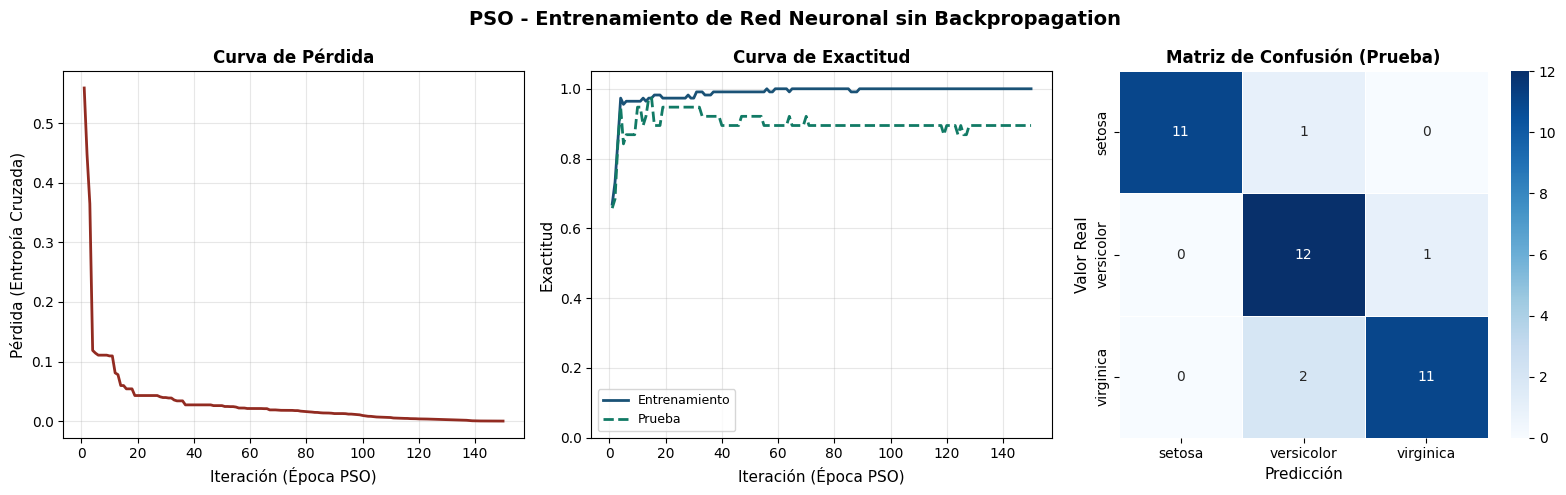

Graficas generadas y guardadas.


In [9]:
# ============================================================
# GRÁFICAS DE ENTRENAMIENTO Y EVALUACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PSO - Entrenamiento de Red Neuronal sin Backpropagation',
             fontsize=14, fontweight='bold')

iters = range(1, len(trainer.loss_history)+1)

# Gráfica 1: Evolución de la pérdida
axes[0].plot(iters, trainer.loss_history, color='#922b21', linewidth=2)
axes[0].set_xlabel('Iteración (Época PSO)', fontsize=11)
axes[0].set_ylabel('Pérdida (Entropía Cruzada)', fontsize=11)
axes[0].set_title('Curva de Pérdida', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Evolución de la exactitud
axes[1].plot(iters, trainer.accuracy_history, color='#1a5276',
             linewidth=2, label='Entrenamiento')
if trainer.val_acc_history:
    axes[1].plot(iters, trainer.val_acc_history, color='#117a65',
                 linewidth=2, linestyle='--', label='Prueba')
axes[1].set_xlabel('Iteración (Época PSO)', fontsize=11)
axes[1].set_ylabel('Exactitud', fontsize=11)
axes[1].set_title('Curva de Exactitud', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

# Gráfica 3: Matriz de confusión
cm_mat = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[2], linewidths=0.5)
axes[2].set_xlabel('Predicción', fontsize=11)
axes[2].set_ylabel('Valor Real', fontsize=11)
axes[2].set_title('Matriz de Confusión (Prueba)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pso_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graficas generadas y guardadas.")